In [4]:
!pip install torch numpy matplotlib seaborn

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.8/113.8 MB 3.4 MB/s eta 0:00:34
    --------------------------------------- 1.6/113.8 MB 2.7 MB/s eta 0:00:42
    --------------------------------------- 2.1/113.8 MB 2.8 MB/s eta 0:00:40
    --------------------------------------- 2.4/113.8 MB 2.5 MB/s eta 0:00:45
    --------------------------------------- 2.6/113.8 MB 2.3 MB/s eta 0:00:49
   - -------------------------------------- 3.4/113.8 MB 2.4 MB/s eta 0:00:46
   - -------------------------------------- 3.7/113.8 MB 2.4 MB/s eta 0:00:46
   - -------------------------------------- 4.2/113.8 MB 2.3 MB/s eta 0:00:48
   - -------------------------------------- 4.7/113.8 MB 2.3 MB/s eta 0:00:48
   - -------------------------------------- 5.5/113.8 MB 2.5 MB/s eta 0:00:44
   -- ------------------------------------- 6.0/113.8 MB 2.5 MB/s eta 0:00:44


Epoch 0: Total Loss 0.901409
Epoch 5000: Total Loss 0.021749
Epoch 10000: Total Loss 0.005386
Epoch 15000: Total Loss 0.002677


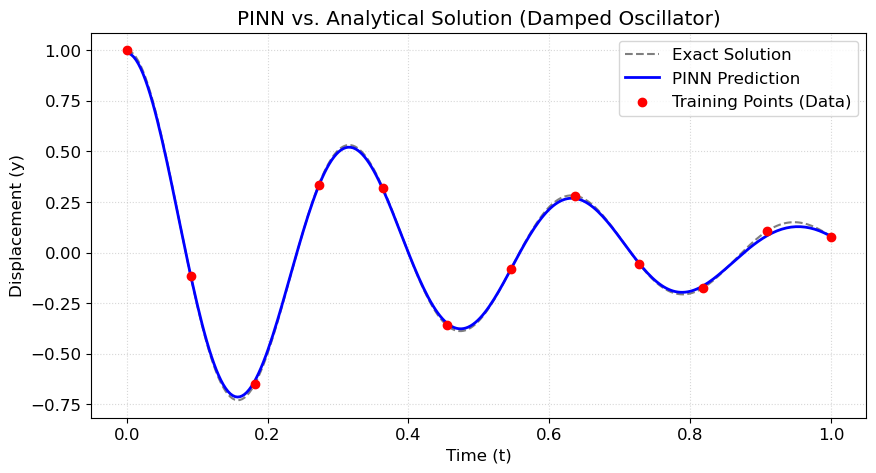

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP & ACCESSIBILITY CONFIG
# Using a color-blind friendly style and high-contrast settings
plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 14})

def oscillator(d, w0, t):
    """
    Analytical solution for a damped harmonic oscillator.
    Used for generating ground truth data.
    """
    assert d < w0, "Oscillation must be underdamped for this tutorial"
    w = np.sqrt(w0**2 - d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = np.exp(-d*t) * np.cos(w*t + phi)
    return 2*A*cos

# 2. THE PINN ARCHITECTURE
class FCN(nn.Module):
    """Fully Connected Network for PINN"""
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh # Tanh is preferred for PINNs (smooth derivatives)
        layers = [nn.Linear(N_INPUT, N_HIDDEN), activation()]
        for _ in range(N_LAYERS - 1):
            layers.append(nn.Linear(N_HIDDEN, N_HIDDEN))
            layers.append(activation())
        layers.append(nn.Linear(N_HIDDEN, N_OUTPUT))
        self.fcn = nn.Sequential(*layers)

    def forward(self, x):
        return self.fcn(x)

# 3. TRAINING PARAMETERS & DATA GENERATION
d, w0 = 2, 20
t_physics = torch.linspace(0, 1, 500).view(-1,1).requires_grad_(True)

# Training data: Only a few points (simulating sparse sensor data)
t_data = torch.linspace(0, 1, 12).view(-1,1)
y_data = torch.tensor(oscillator(d, w0, t_data.numpy()), dtype=torch.float32)

# 4. TRAINING LOOP
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mu, k = 2*d, w0**2 # Physics constants

for i in range(15001):
    optimizer.zero_grad()
    
    # Loss 1: Data-driven loss (MSE)
    yh = model(t_data)
    loss1 = torch.mean((yh - y_data)**2)
    
    # Loss 2: Physics-informed loss
    # We use autograd to find derivatives of y with respect to time t
    y_physics = model(t_physics)
    dy  = torch.autograd.grad(y_physics, t_physics, torch.ones_like(y_physics), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, t_physics, torch.ones_like(dy), create_graph=True)[0]
    
    # ODE: ddy + mu*dy + k*y = 0
    physics_residual = ddy + mu*dy + k*y_physics
    loss2 = (1e-4) * torch.mean(physics_residual**2) # Weighting the physics loss
    
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
    
    if i % 5000 == 0:
        print(f"Epoch {i}: Total Loss {loss.item():.6f}")

# 5. VISUALIZATION (REPRODUCIBLE & ACCESSIBLE)
t_test = torch.linspace(0, 1, 300).view(-1,1)
y_pred = model(t_test).detach().numpy()
y_true = oscillator(d, w0, t_test.numpy())

plt.figure(figsize=(10, 5))
plt.plot(t_test, y_true, label='Exact Solution', color='black', alpha=0.5, linestyle='--')
plt.plot(t_test, y_pred, label='PINN Prediction', color='blue', linewidth=2)
plt.scatter(t_data, y_data, color='red', label='Training Points (Data)', zorder=5)

plt.title("PINN vs. Analytical Solution (Damped Oscillator)")
plt.xlabel("Time (t)")
plt.ylabel("Displacement (y)")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()